In [99]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [100]:
Rx_riferimento = 1.9515 * 1000

data = {
    "Metodo B" : {
        "R_star": np.array([
            1958.439794,
            1955.207868,
            1953.931427,
            1951.936258,
            1951.333062,
            1951.340807,
            1952.307366,
            1952.349405,
            1952.386423,
            1951.41712,
            1952.448052,
            1952.423661,
            1951.487713,
            1951.510759,
            1951.51888
        ]),

        "R_corr" : np.array([
            1955.733333,
            1954.059874,
            1953.862857,
            1946.299571,
            1950.175626,
            1951.423529,
            1947.555123,
            1944.772282,
            1951.802945,
            1952.246772,
            1948.08366,
            1942.013603,
            1950.794417,
            1949.889855,
            1953.918584,
        ]),

        "R_inv_corr" : np.array([
            1961.15,
            1956.356537,
            1954.0,
            1957.58927,
            1952.491186,
            1951.258088,
            1957.071204,
            1959.956049,
            1952.970076,
            1950.58782,
            1956.822222,
            1962.889522,
            1952.181256,
            1953.133011,
            1949.122124,
        ])
    },

    "Metodo A": {
        "R_star" : np.array([
            #1966.49013,
            1959.141026,
            #1994.308571,
            1952.268877,
            1951.447437,
            1951.500716,
            1951.383162,
            1952.338142,
            1952.464041,
            1951.557128,
            1946.586901,
            1951.51833,
            1951.562499,
            1951.559069,
            1952.559667
        ]),

        "R_corr" : np.array([
            #1968.95,
            1959.222182,
            #1994.268571,
            1948.385408,
            1950.512949,
            1951.776471,
            1947.6,
            1944.818224,
            1951.958138,
            1952.526918,
            1946.260131,
            1940.13125,
            1950.899103,
            1949.938164,
            1953.971681,
        ]),

        "R_inv_corr" : np.array([
            #1964.033333,
            1959.059874,
            #1994.348571,
            1956.160086,
            1952.382372,
            1951.225,
            1955.173672,
            1959.887136,
            1952.970076,
            1950.58782,
            1946.913725,
            1962.972243,
            1952.226122,
            1953.18132,
            1951.148673,
        ])
    },

    "R_AB" : {

        "R_A" : np.array([
            27.14,
            46.92,
            99.93,
            219.67,
            329.51,
            389.52,
            469.39,
            558.31,
            680.05,
            747.08,
            1001.9,
            1205.9,
            1496.8,
            1797.3,
            2202.7,
        ]),

        "R_B" : np.array([
            27.17,
            46.97,
            99.8,
            220.21,
            329.66,
            389.51,
            470.38,
            560.44,
            680.25,
            746.67,
            1004.3,
            1212.4,
            1497.8,
            1799.4,
            2200.9,
        ])

    },

    "k" : np.array([
        1.666666667,
        1.352569883,
        1.142857143,
        1.072961373,
        1.088139282,
        1.102941176,
        1.121914734,
        1.148545176,
        1.19379228,
        1.218026797,
        1.307189542,
        1.378676471,
        1.49551346,
        1.610305958,
        1.769911504
    ]),

    "rho" : np.array([
        0.998895841,
        0.9989354907,
        1.001302605,
        0.9975477953,
        0.9995449857,
        1.000025673,
        0.9978953187,
        0.9961994147,
        0.9997059904,
        1.000549105,
        0.9976102758,
        0.9946387331,
        0.9993323541,
        0.9988329443,
        1.000817847,
    ]),

    "sigma_rho" : np.array([
        0.002537434164,
        0.001611567849,
        0.001047540664,
        0.0008667016728,
        0.0008398230726,
        0.0008335610131,
        0.0008265026096,
        0.0008216698895,
        0.0008218834713,
        0.00082161804,
        #errori finti da qui in poi
        0.0008335610131,
        0.0008265026096,
        0.0008216698895,
        0.0008218834713,
        0.00082161804,
    ])
}

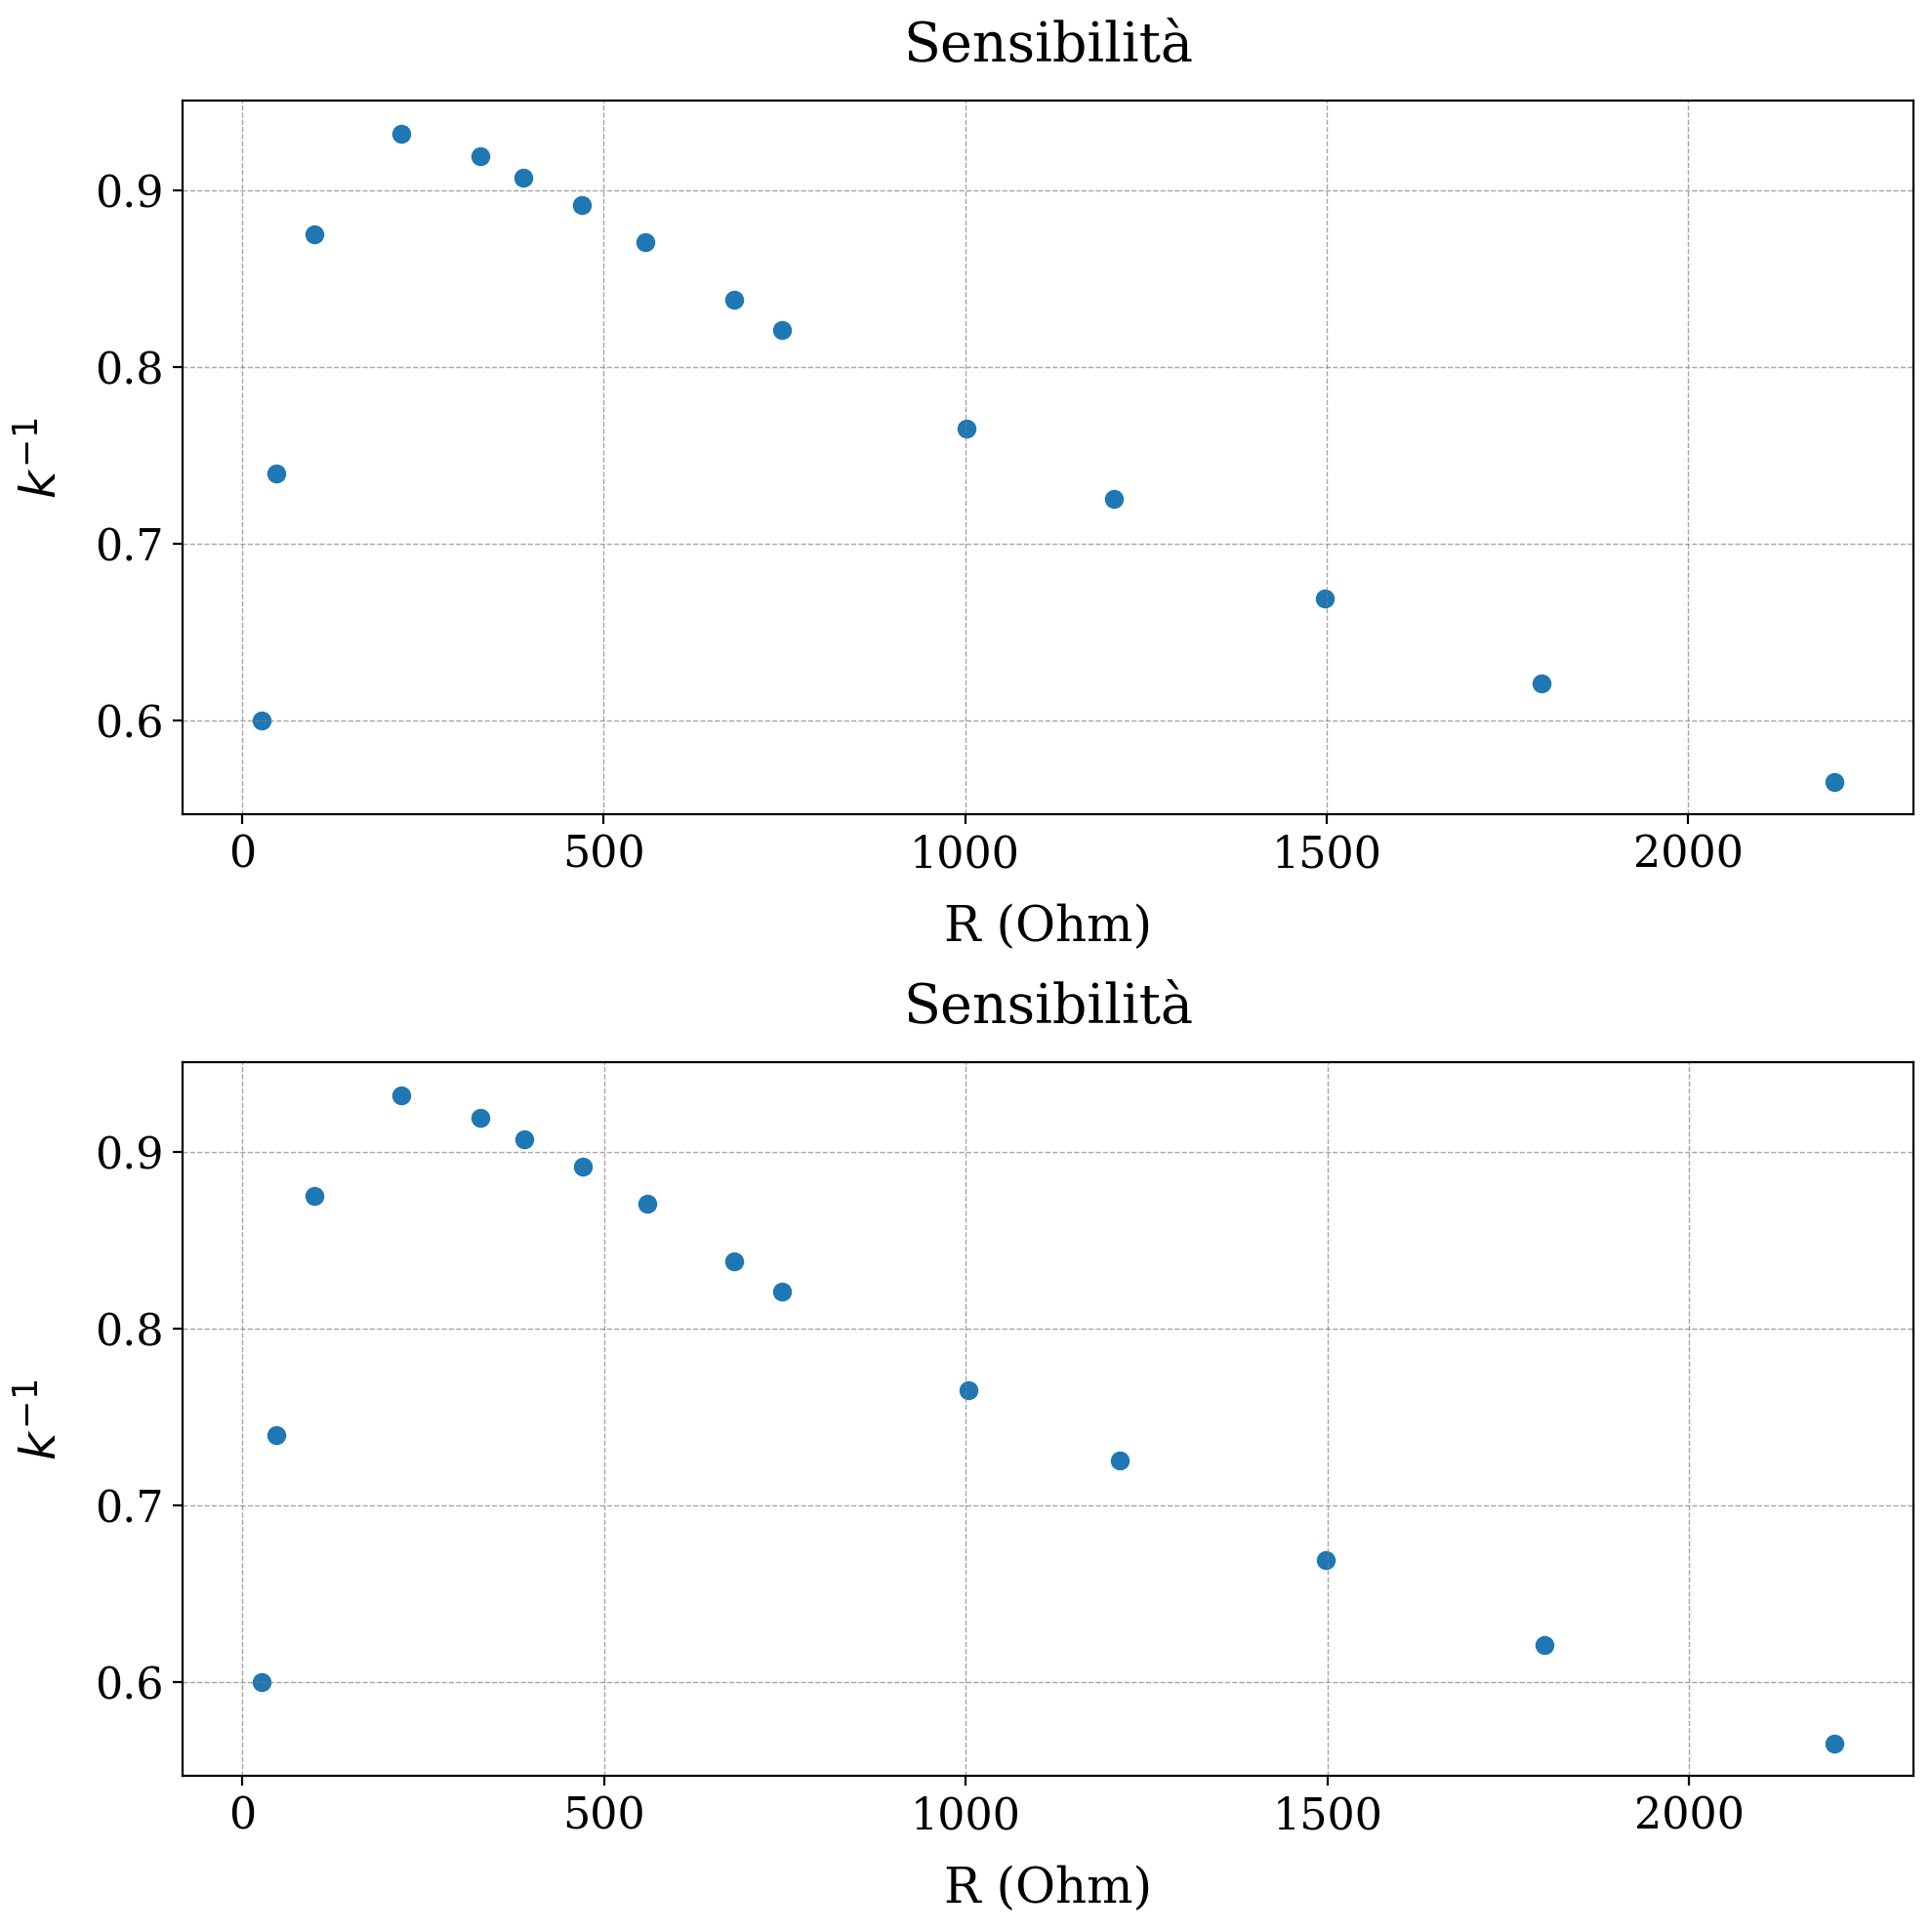

In [101]:
titolo="Sensibilità"
fig,axes = plt.subplots(2, 1,  figsize=(10, 5*2))
k = 1/data["k"]
for i,dati in enumerate(data["R_AB"].values()):
    ax = axes[i]
    gf.parametri_grafico(ax,titolo,xlabel="R (Ohm)",ylabel=r"$k^{-1}$")
    ax.scatter(dati, k)

gf.salva_grafico(fig,f"{titolo}.pdf")

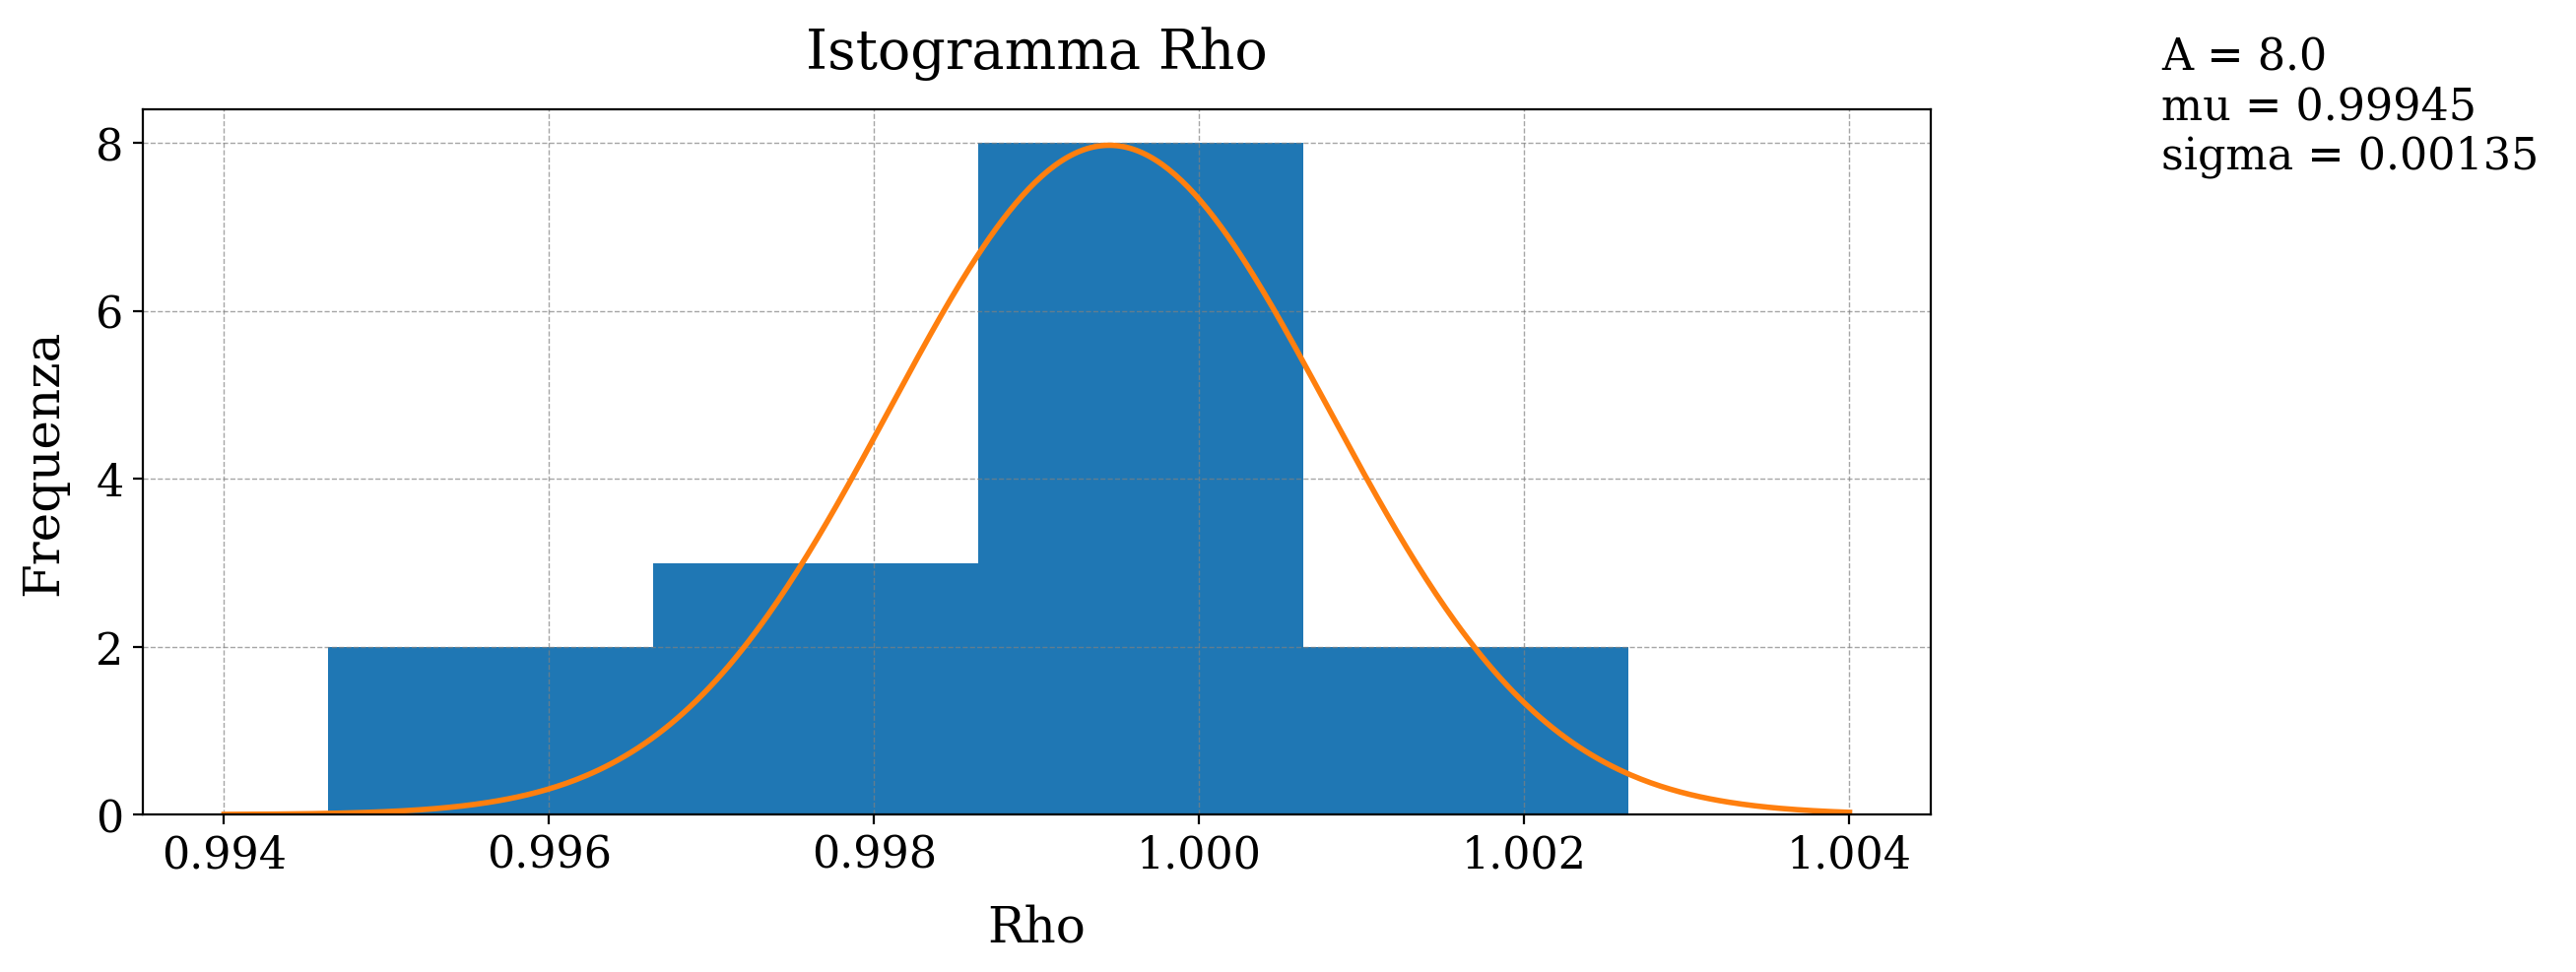

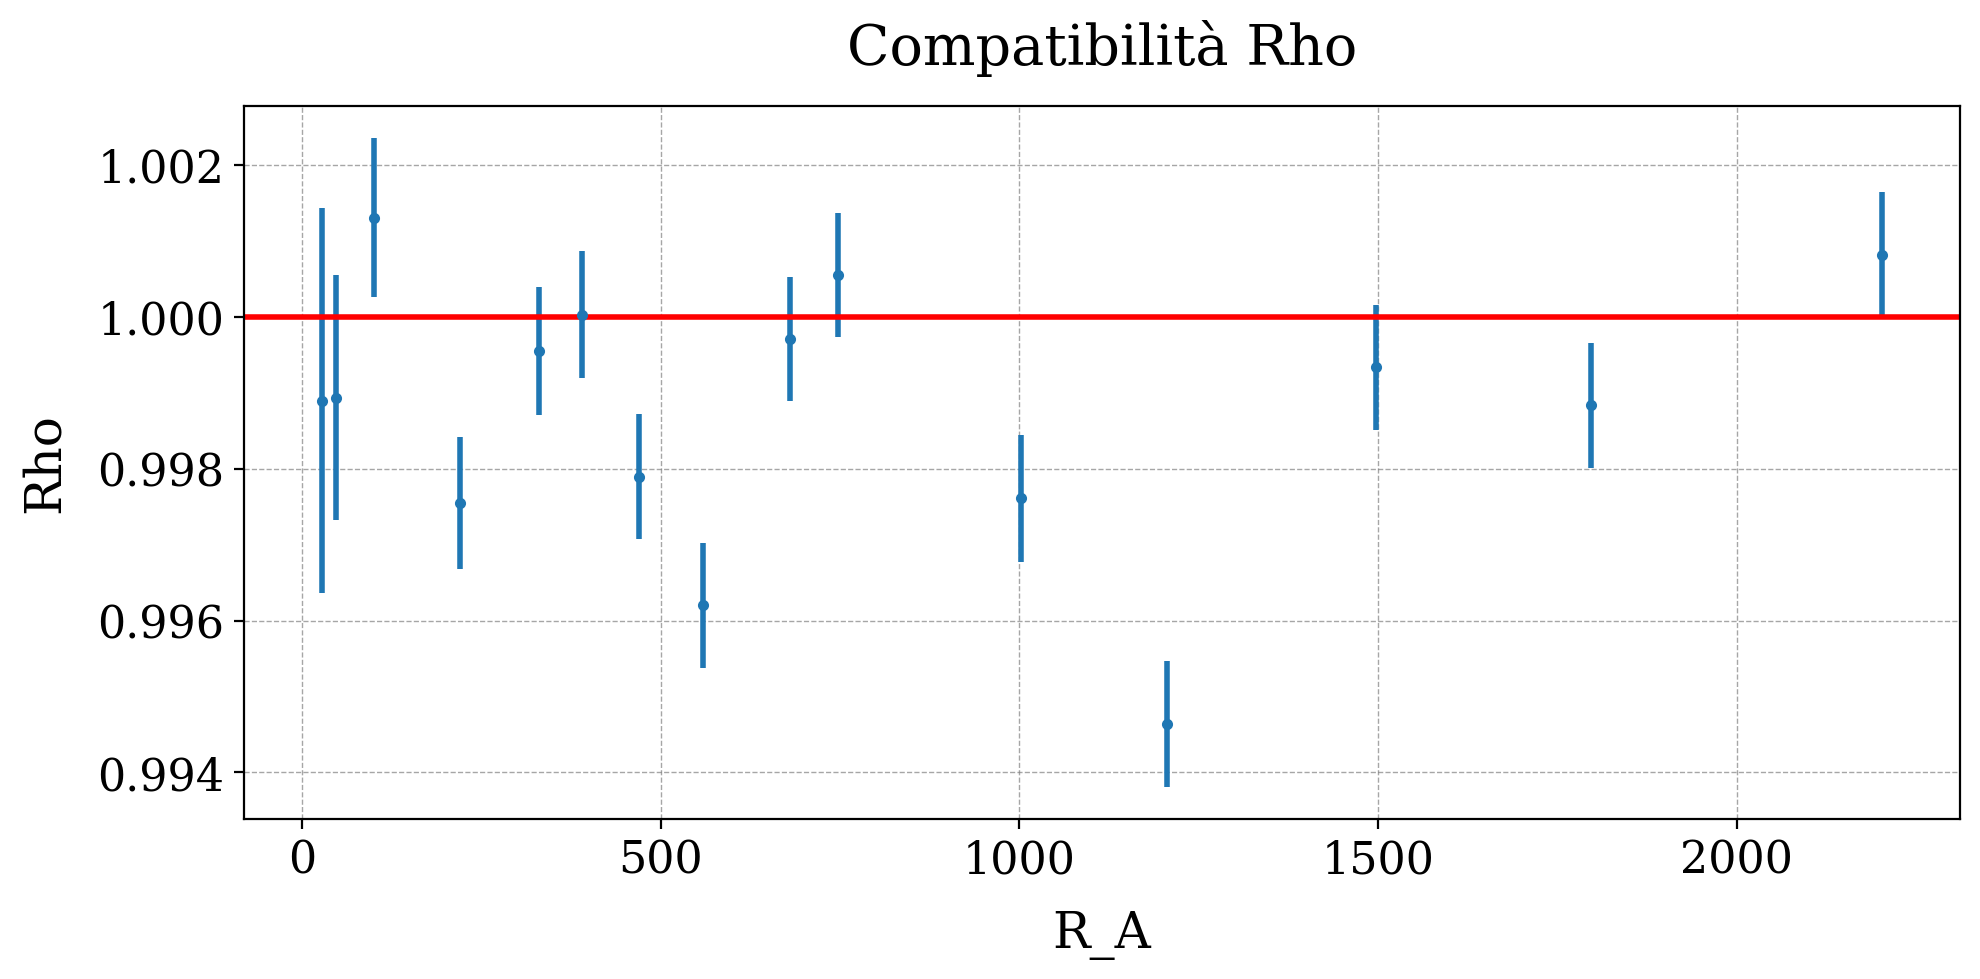

0.9987889582533334
0.001721694872224246


In [ ]:
from scipy.optimize import curve_fit

titolo1 = "Istogramma Rho"
titolo2 = "Compatibilità Rho"
dati = data["rho"]
errori = data["sigma_rho"]

fig1,ax1 = plt.subplots(1, 1,  figsize=(10, 5), sharex=True, sharey=True)

h = 0.002
bins = np.arange(dati.min(), dati.max() + h, h)

counts, edges = np.histogram(dati, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2

def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

p0 = [counts.max(), np.mean(dati), np.std(dati)]
popt, pcov = curve_fit(gauss, centers, counts, p0=p0)
A_fit, mu_fit, sigma_fit = popt

ax1.hist(dati, bins=bins)
x = np.linspace(0.994, 1.004, 500)
ax1.plot(x, gauss(x, A_fit, mu_fit, sigma_fit))
gf.parametri_grafico(ax1,titolo1,xlabel="Rho",ylabel="Frequenza")

legenda = (
    f"A = {A_fit:.1f}\n"
    f"mu = {mu_fit:.5f}\n"
    f"sigma = {sigma_fit:.5f}"
)
gf.descrizione_legenda(ax1,legenda)

gf.salva_grafico(fig1,f"{titolo1}.pdf")

fig2,ax2 = plt.subplots(1, 1,  figsize=(10, 5), sharex=True, sharey=True)
gf.parametri_grafico(ax2,titolo2,xlabel="R_A",ylabel="Rho")
ax2.errorbar(data["R_AB"]["R_A"],dati,errori,fmt=".")
ax2.axhline(y=1, color="red")
gf.salva_grafico(fig2,f"{titolo2}.pdf")

print(np.mean(dati))
print(np.std(dati))

In [103]:
gf.display_dizionario(data)

In [106]:
import numpy as np

def errore_media(array):
    """
    Calcola l'errore standard della media di un array di dati.
    
    Parametri:
    ----------
    array : np.ndarray o lista
        Dati numerici.
    
    Ritorna:
    -------
    float
        Errore standard della media.
    """
    array = np.array(array)  # assicura che sia un array NumPy
    N = array.size           # numero di elementi
    sigma = np.std(array, ddof=1)  # deviazione standard campionaria
    return sigma / np.sqrt(N)

def vettore(array):
    return [np.mean(array), errore_media(array)]

In [120]:
sys = 0.8414674671

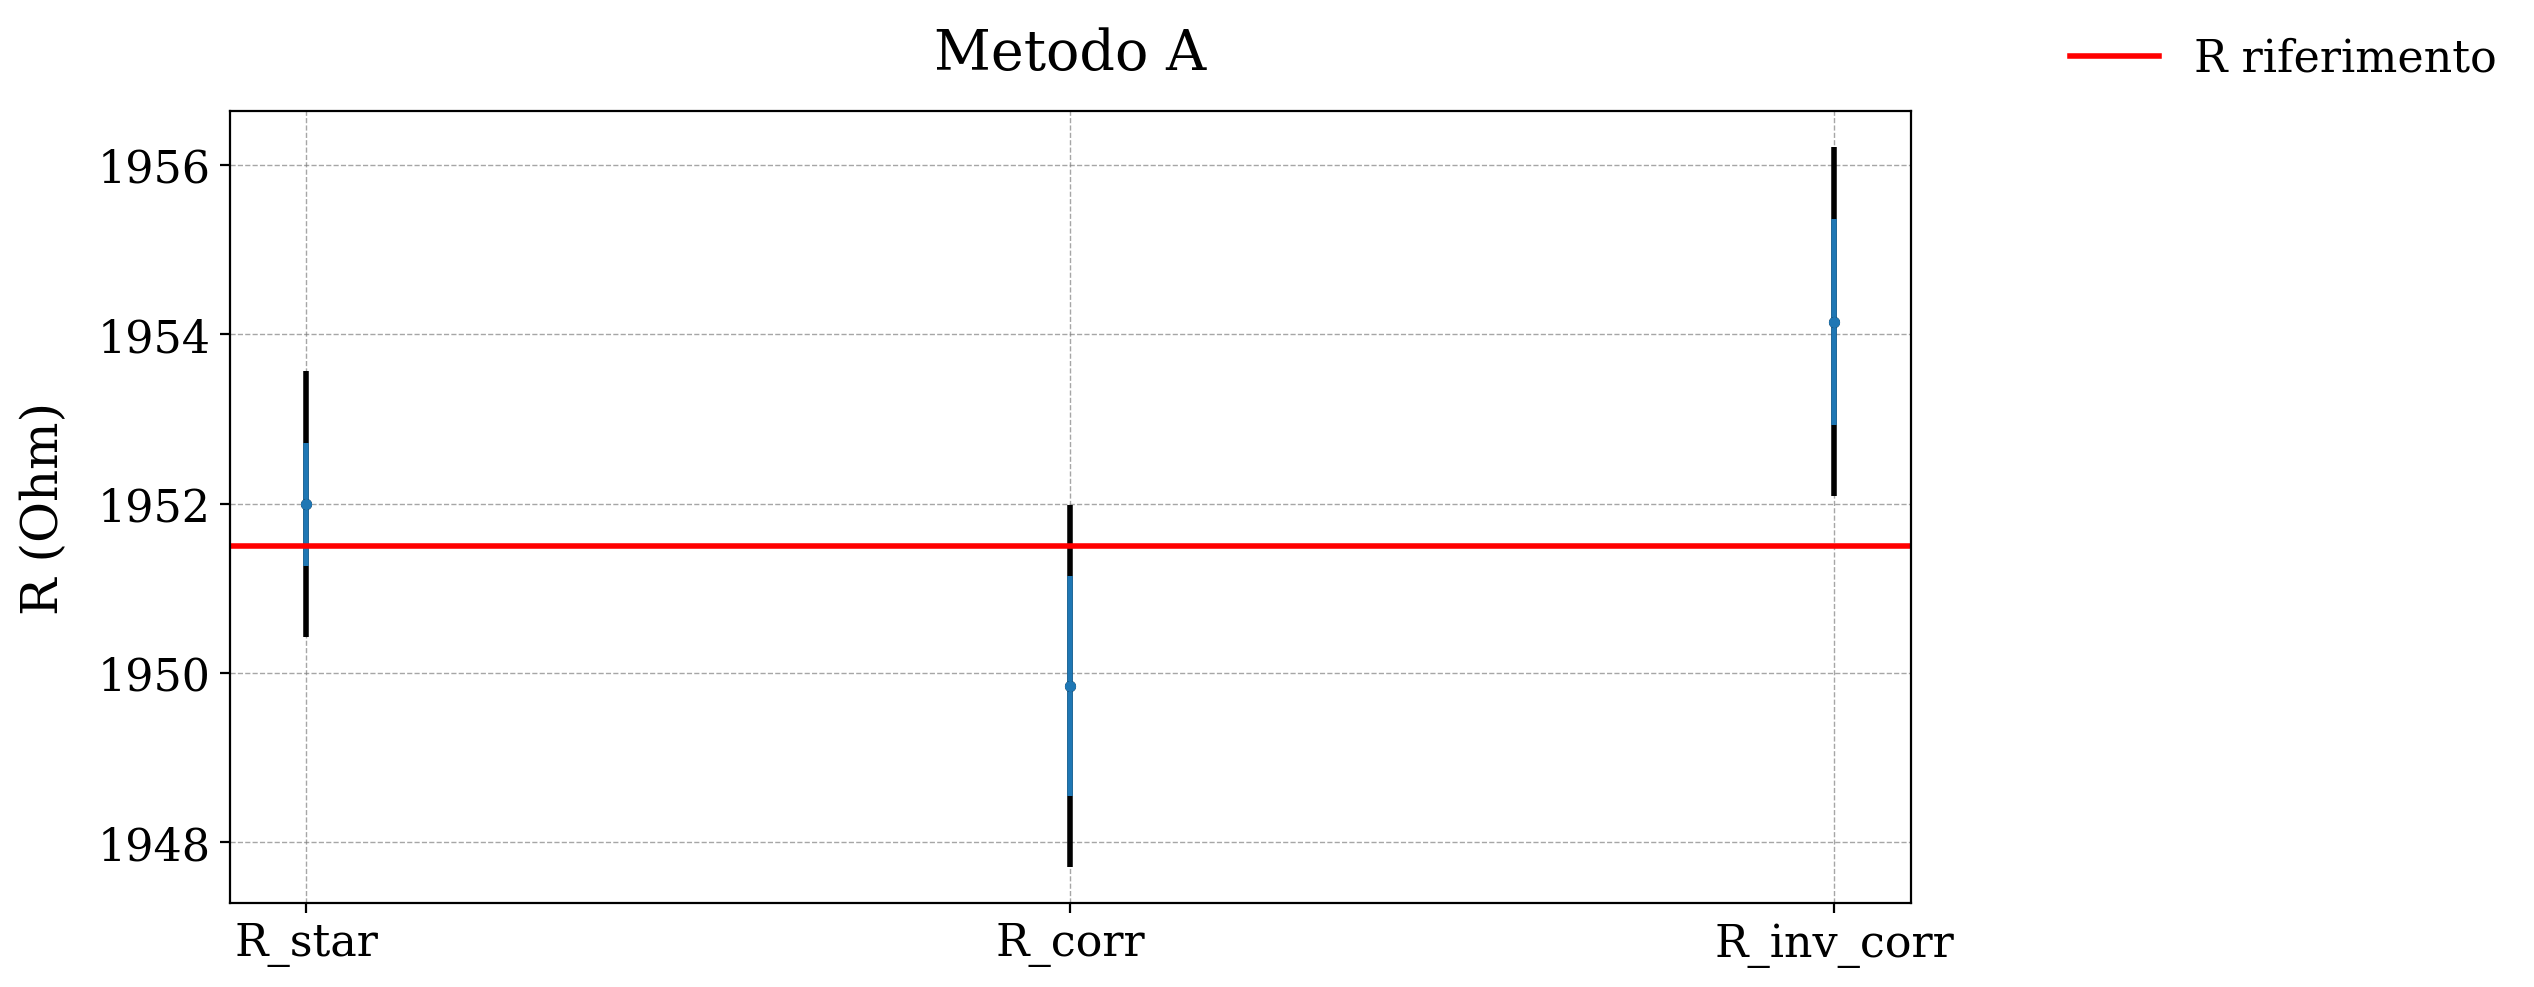

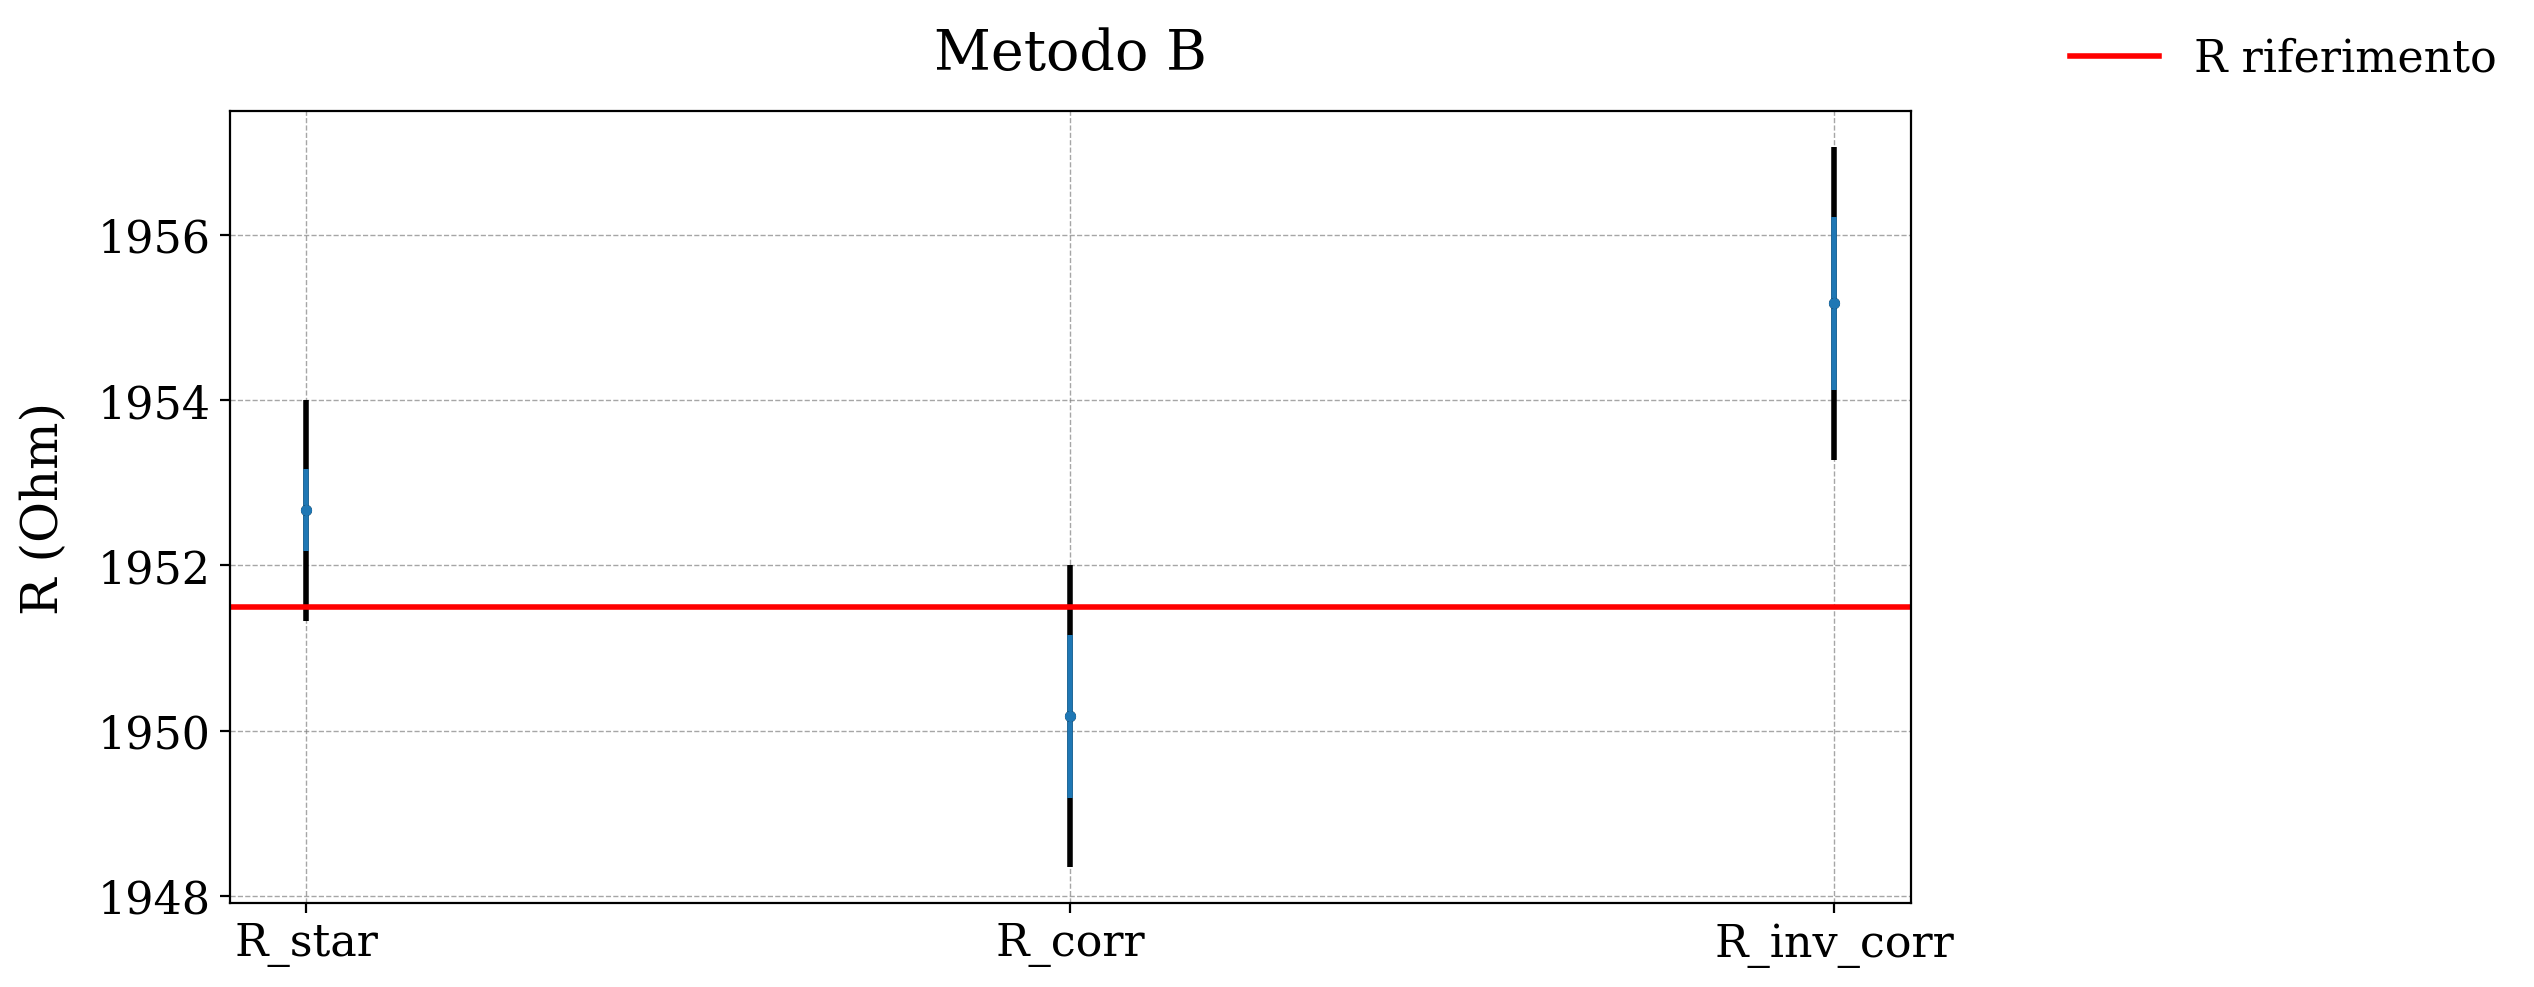

In [134]:
for i, metodo  in enumerate(["Metodo A", "Metodo B"]):
    dati = data[metodo]
    valori = {
        "R_star" : vettore(dati["R_star"])[0],
        "R_corr" : vettore(dati["R_corr"])[0],
        "R_inv_corr" : vettore(dati["R_inv_corr"])[0]
    }
    incertezze = {
        "R_star" : vettore(dati["R_star"])[1],
        "R_corr" : vettore(dati["R_corr"])[1],
        "R_inv_corr" : vettore(dati["R_inv_corr"])[1]
    }

    fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
    gf.parametri_grafico(ax,metodo,xlabel="",ylabel="R (Ohm)")
    labels = ["R_star", "R_corr", "R_inv_corr"]
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(labels)
    ax.errorbar([1,2,3], valori.values(), np.array(list(incertezze.values())) + sys, fmt=".", color="black")
    ax.errorbar([1,2,3], valori.values(), incertezze.values(), fmt=".")
    ax.axhline(y=Rx_riferimento, color="red", label="R riferimento")
    gf.salva_grafico(fig,f"Confronto R {metodo}.pdf")